In [82]:
import importlib
import NeuralNetwork
import funcs

importlib.reload(NeuralNetwork)
importlib.reload(funcs)
from NeuralNetwork import NeuralNetwork

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import defaultdict
import numpy as np
from tqdm import tqdm

In [83]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device being used: {device.type}")

device being used: cuda


## Global parameters

In [ ]:
# model parameters
HIDDEN_LAYERS = [512, 256, 128]
TRAIN_VAL_SPLIT = 0.8

# initial training
N_TRAIN_EPOCHS = 15 if device.type == "cuda" else 8

# pruning loop
MAX_ALLOWED_ACC_DROP = 0.02
MAX_PRUNE_ROUNDS = 15
PRUNE_FRAC = 0.2
REGROW_FRAC = 0.1
MIN_VAL_ACC = 0.9
N_RETRIAN_EPOCHS = 3

# clustering
N_CLUSTERS = 10

## Setting up data and initial model

In [85]:
# Define a transform to convert images to PyTorch tensors
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.rot90(x, k=-1, dims=[1,2])),
    transforms.Lambda(lambda x: torch.flip(x, dims=[2]))
])

# Download and load the training set
train_dataset = datasets.EMNIST(
    root="./data",       # where to store the data
    split="digits",      # "digits" for 0–9, other options: "letters", "balanced", etc.
    train=True,
    download=True,
    transform=transform
)

# Download and load the test set
test_dataset = datasets.EMNIST(
    root="./data",
    split="digits",
    train=False,
    download=True,
    transform=transform
)

In [86]:
train_size = int(TRAIN_VAL_SPLIT * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
print(f"train size: {train_size}, val size: {val_size}, test size: {len(test_dataset)}")

train size: 192000, val size: 48000, test size: 40000


In [87]:
# Create a DataLoader for batching
batch_size = 256 if device.type == "cuda" else 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [88]:
# Create model and train
model = NeuralNetwork(hidden_sizes=HIDDEN_LAYERS, device=device)

In [89]:
metrics = model.train_model(train_loader=train_loader, val_loader=val_loader, epochs=N_TRAIN_EPOCHS)
print(metrics)

       train_loss  train_acc  val_loss   val_acc
epoch                                           
1        0.271588   0.949411  0.106601  0.968854
2        0.194218   0.971776  0.095610  0.972688
3        0.184304   0.972714  0.074693  0.978896
4        0.174669   0.974521  0.082416  0.975938
5        0.166733   0.975740  0.093282  0.973771
6        0.166129   0.975187  0.089882  0.973833
7        0.166027   0.974833  0.084385  0.975792
8        0.163284   0.976000  0.086397  0.975125
9        0.161037   0.975927  0.091401  0.972750
10       0.160708   0.975849  0.079886  0.977458
11       0.158630   0.976266  0.098147  0.971812
12       0.159408   0.976063  0.086588  0.974208
13       0.156405   0.976453  0.083660  0.975708
14       0.155233   0.976526  0.084587  0.975708
15       0.158079   0.976542  0.088947  0.974958


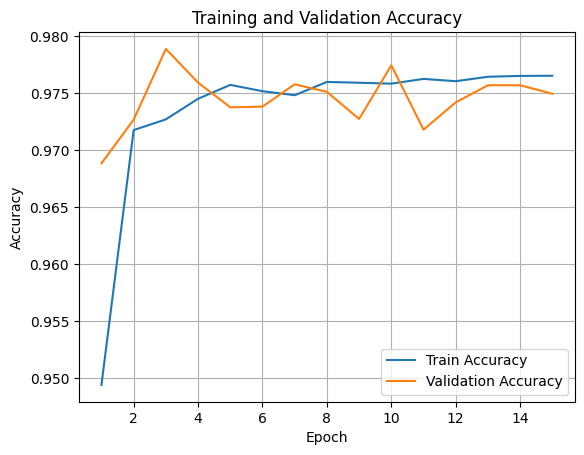

In [90]:
funcs.plot_accuracy(metrics)

## Prune Neurons and Retrain

In [ ]:
prune_parameters = (MAX_PRUNE_ROUNDS, PRUNE_FRAC, REGROW_FRAC, N_RETRIAN_EPOCHS, MAX_ALLOWED_ACC_DROP)
use_max_rounds = False if device.type == "cuda" else True
final_model, final_val_acc, metrics_history = funcs.pruning(model, train_loader, val_loader, prune_parameters, use_max_rounds)


--- Pruning round 2 ---
Getting layer data:


100%|██████████| 750/750 [00:13<00:00, 54.04it/s]


Retraining:


Epoch 3/3:  95%|█████████▌| 893/938 [00:15<00:00, 73.36it/s]

In [ ]:
for round_idx, metrics in enumerate(metrics_history, start=1):
    print(f"--- Round {round_idx} ---")
    final_val_acc = metrics['val_acc'].iloc[-1]
    print(f"Final validation accuracy: {final_val_acc:.5f}")

--- Round 1 ---
Final validation accuracy: 0.97467


In [ ]:
print(f"Test accuracy after pruning: {final_model.accuracy(test_loader)*100:.2f}")

  0%|          | 0/157 [00:00<?, ?it/s]

100%|██████████| 157/157 [00:02<00:00, 67.15it/s]

Test accuracy after pruning: 97.46


## Activation analysis and Neuron Clustering

We create a new data loader that does not shuffle the data so our instances match up with our data

In [ ]:
analysis_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
layer_data_analysis = final_model.get_layer_data(analysis_loader)

100%|██████████| 750/750 [00:13<00:00, 54.43it/s]


In [ ]:
for key, value in layer_data_analysis.items():
    print(f"{key} has shape: {value['post_activation'].shape}")

layer_0 has shape: torch.Size([192000, 420])
layer_1 has shape: torch.Size([192000, 210])
layer_2 has shape: torch.Size([192000, 105])
layer_3 has shape: torch.Size([192000, 10])


In [ ]:
hidden_layers = [k for k in layer_data_analysis.keys() if 'layer_' in k]

all_neuron_activations = []
for layer_name in hidden_layers:
    acts = layer_data_analysis[layer_name]['post_activation']
    all_neuron_activations.append(acts)

all_neuron_activations = torch.cat(all_neuron_activations, dim=1)

In [ ]:
layer_mapping = []
start_idx = 0
for layer_name in hidden_layers:
    n_neurons = layer_data_analysis[layer_name]['post_activation'].shape[1]
    end_idx = start_idx + n_neurons
    layer_mapping.append((layer_name, start_idx, end_idx))
    start_idx = end_idx

In [ ]:
labels = []
images = []
for X, y in tqdm(analysis_loader):
    labels.append(y)
    images.append(X)
labels = torch.cat(labels, dim=0)
images = torch.cat(images, dim=0)

100%|██████████| 750/750 [00:09<00:00, 82.15it/s]


## Clustering

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster

neurons_for_clustering = all_neuron_activations.T.numpy()

Z = linkage(neurons_for_clustering, method='ward', metric='euclidean')

n_clusters = N_CLUSTERS
clusters = fcluster(Z, t=n_clusters, criterion='maxclust')

print(f"Total neurons clustered: {neurons_for_clustering.shape[0]}")
print(f"Clusters assigned: {np.unique(clusters)}")

Total neurons clustered: 745
Clusters assigned: [ 1  2  3  4  5  6  7  8  9 10]


In [ ]:
cluster_map = defaultdict(list)
for neuron_idx, cluster_id in enumerate(clusters):
    cluster_map[cluster_id].append(neuron_idx)

## Cluster selectivity analysis

In [ ]:
selectivity_results = funcs.compute_cluster_selectivity(cluster_map, all_neuron_activations, labels)

In [ ]:
funcs.plot_cluster_activation_heatmap(selectivity_results)

## Cluster ablation

In [ ]:
cluster_results = {}
for cluster_id, neuron_indices in cluster_map.items():
    per_class_acc = funcs.cluster_criticality_per_class(
        final_model,
        neuron_indices,
        layer_mapping,
        val_loader,
        cluster_id,
        device=device
    )
    cluster_results[cluster_id] = per_class_acc


--- Calculating pre and post-ablation accuracy for cluster 6 ---


100%|██████████| 188/188 [00:02<00:00, 78.70it/s]


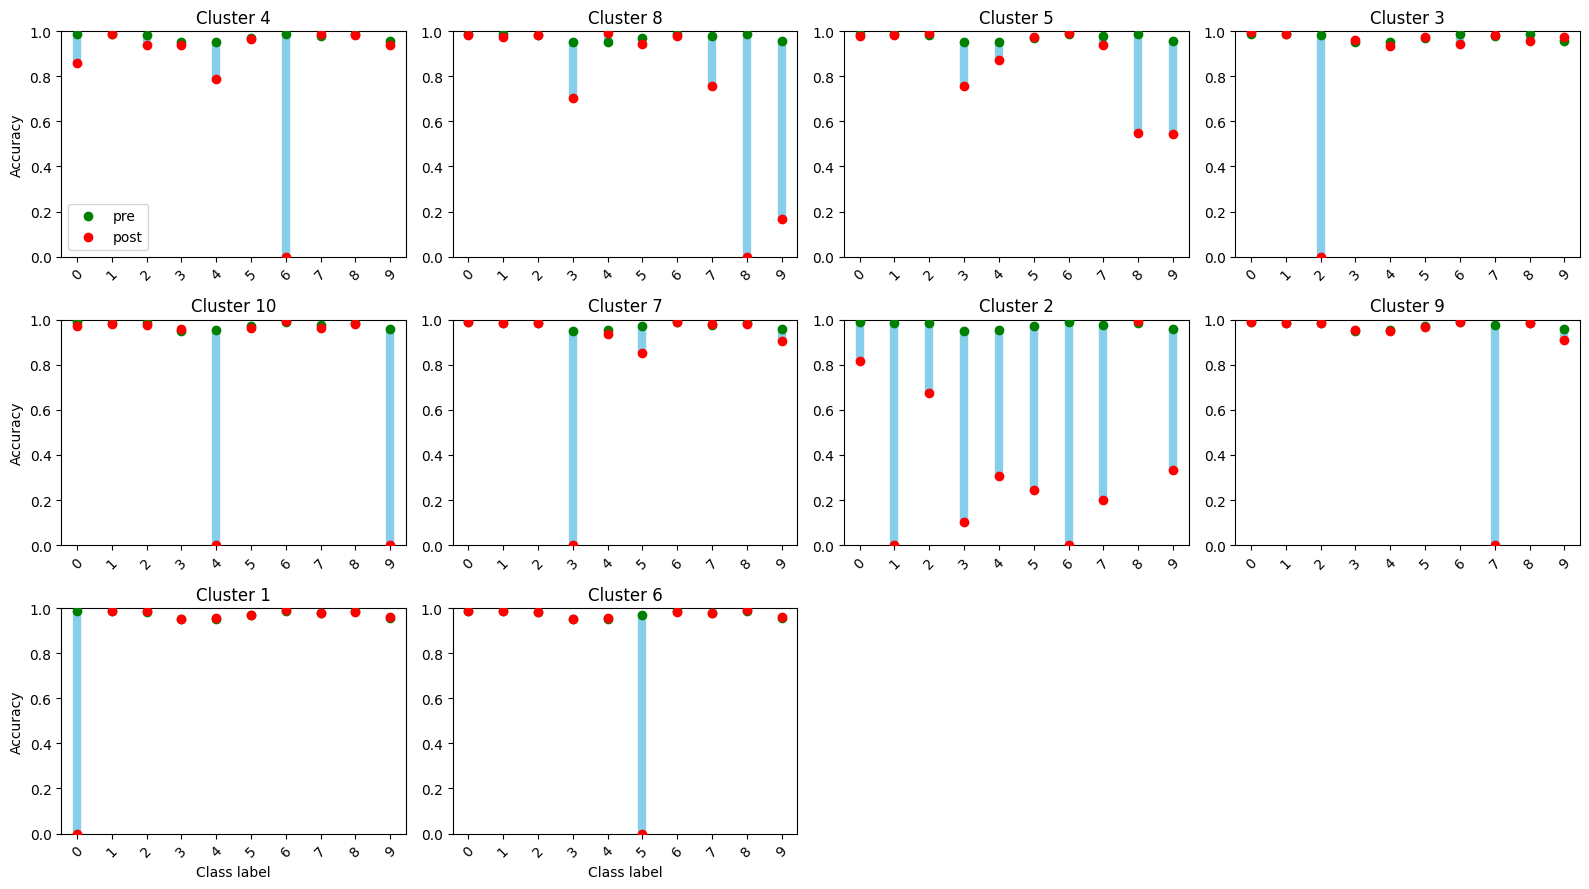

In [ ]:
cluster_class_changes = funcs.plot_cluster_accuracy_bars(cluster_results, target_labels=list(range(10)))

## Prototype and difference map plots

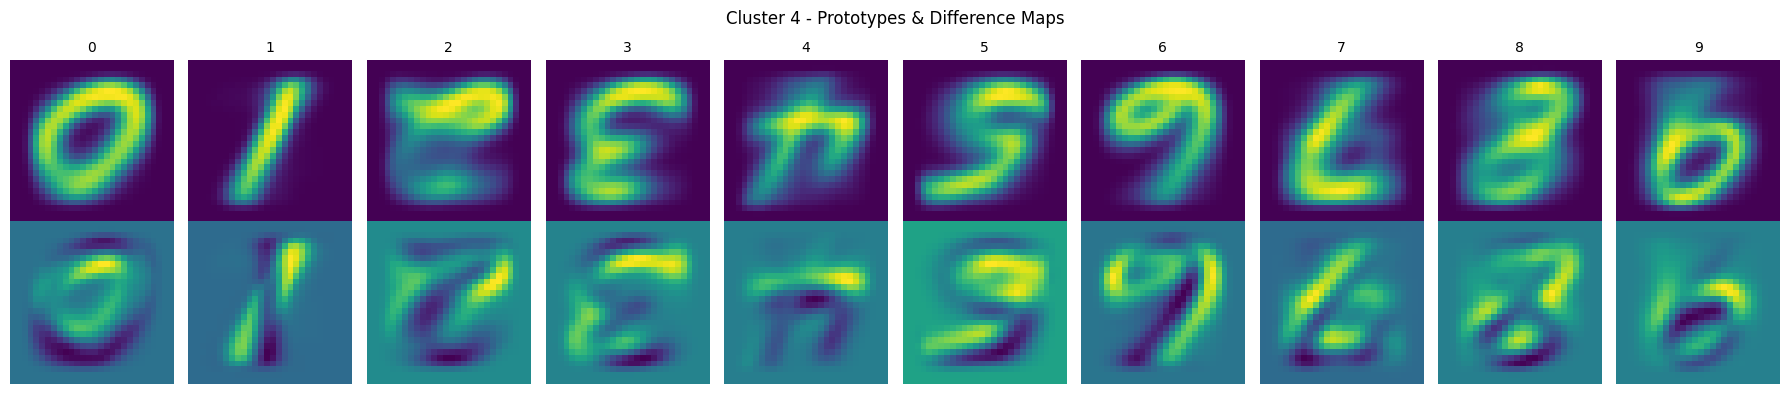

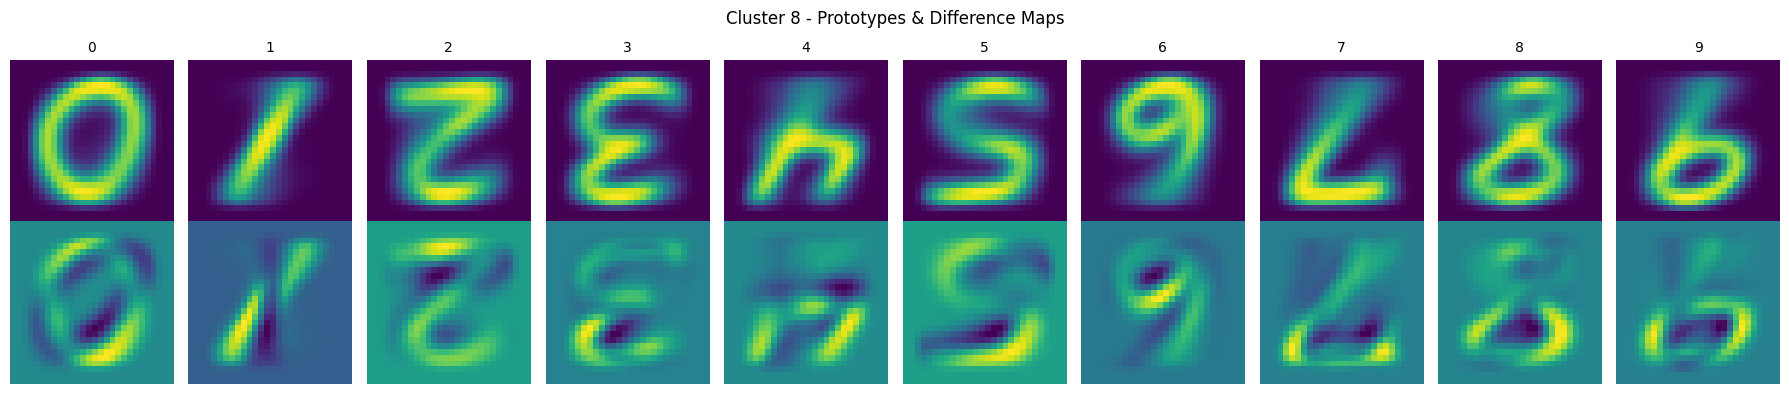

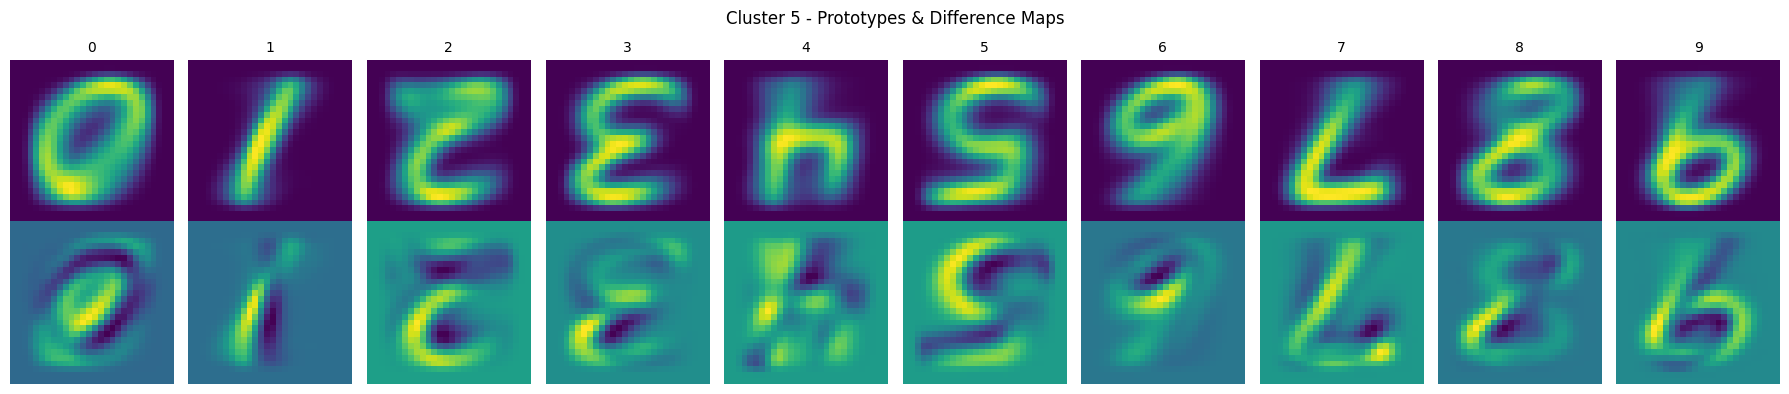

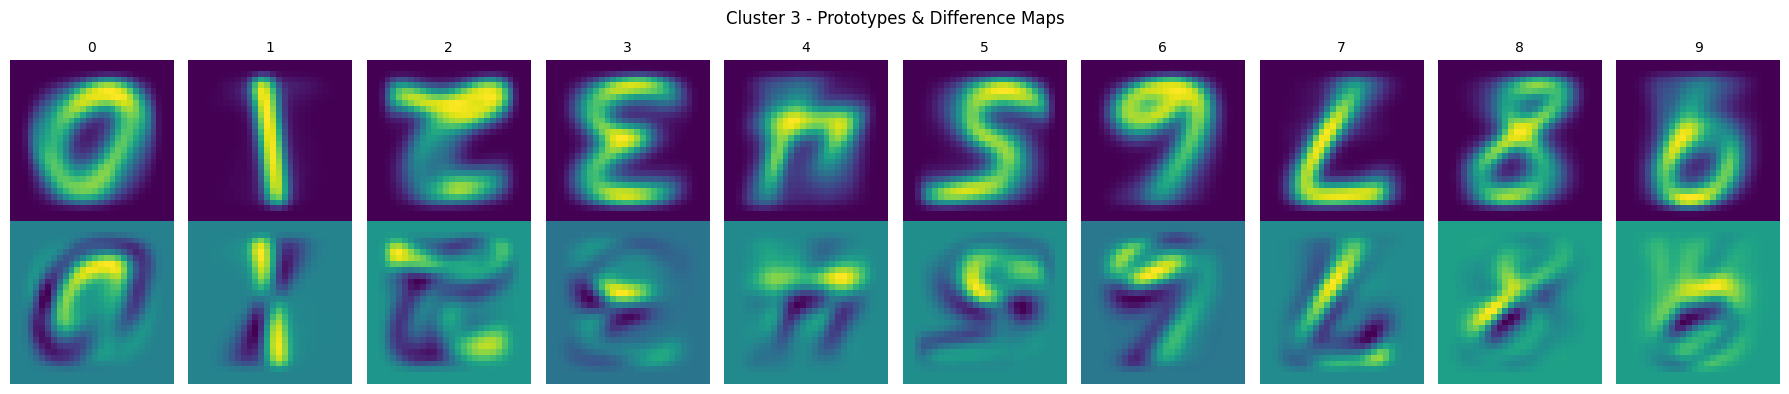

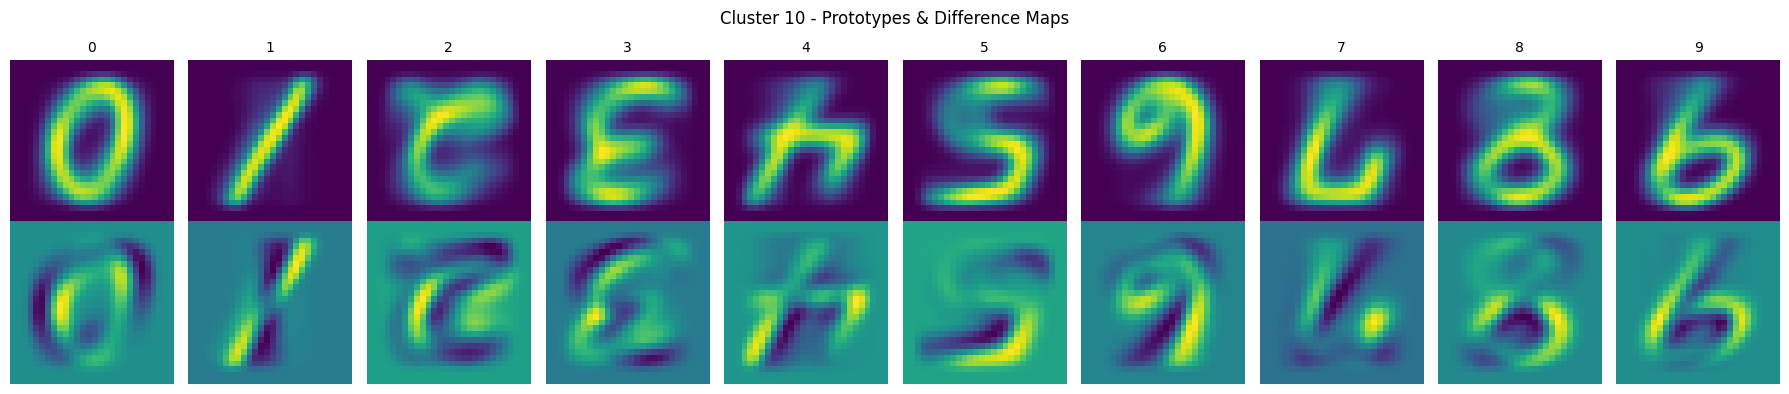

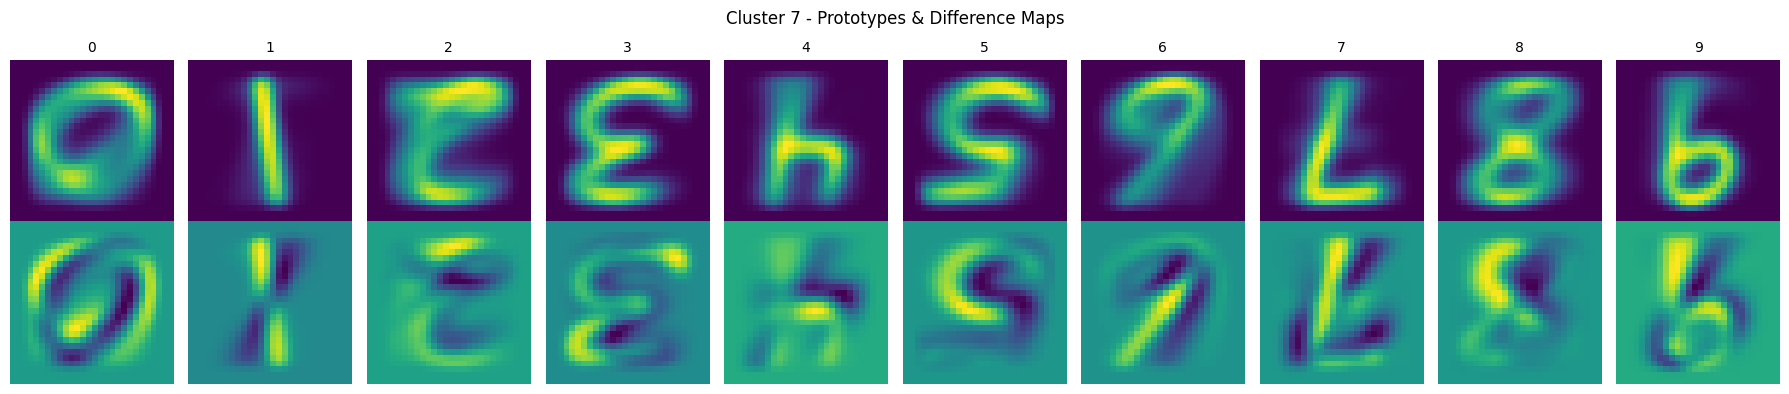

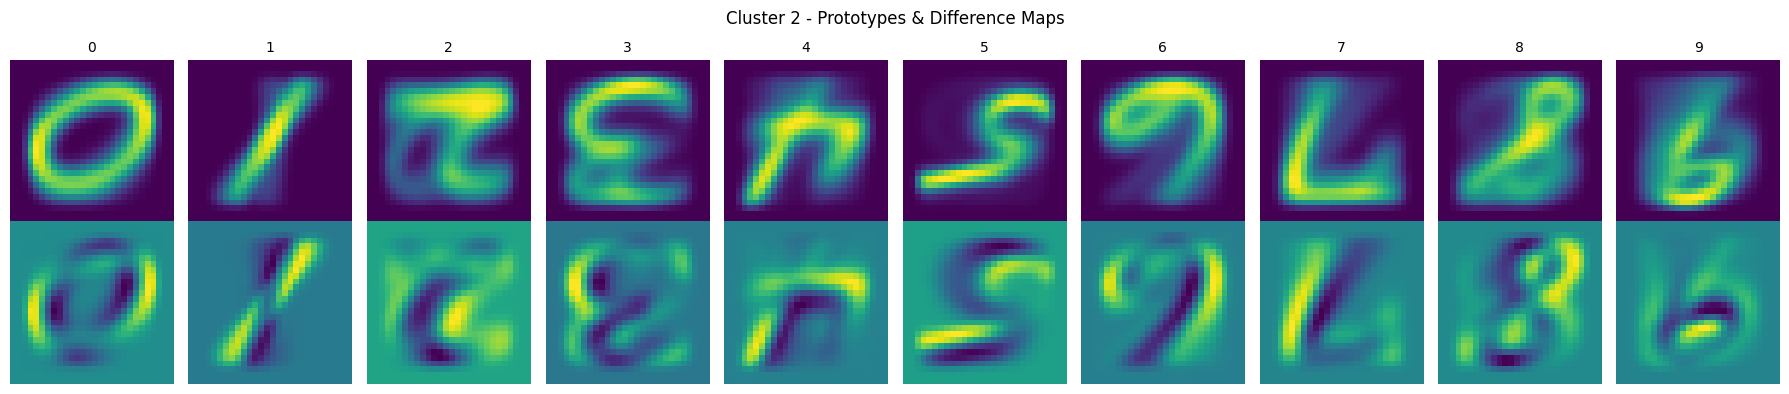

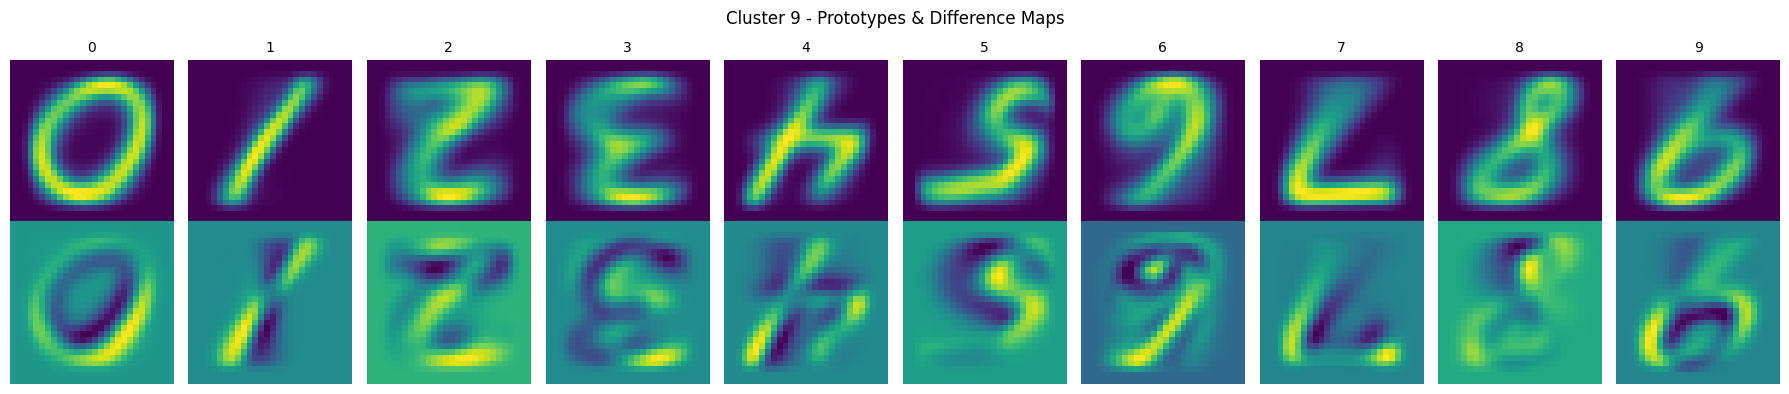

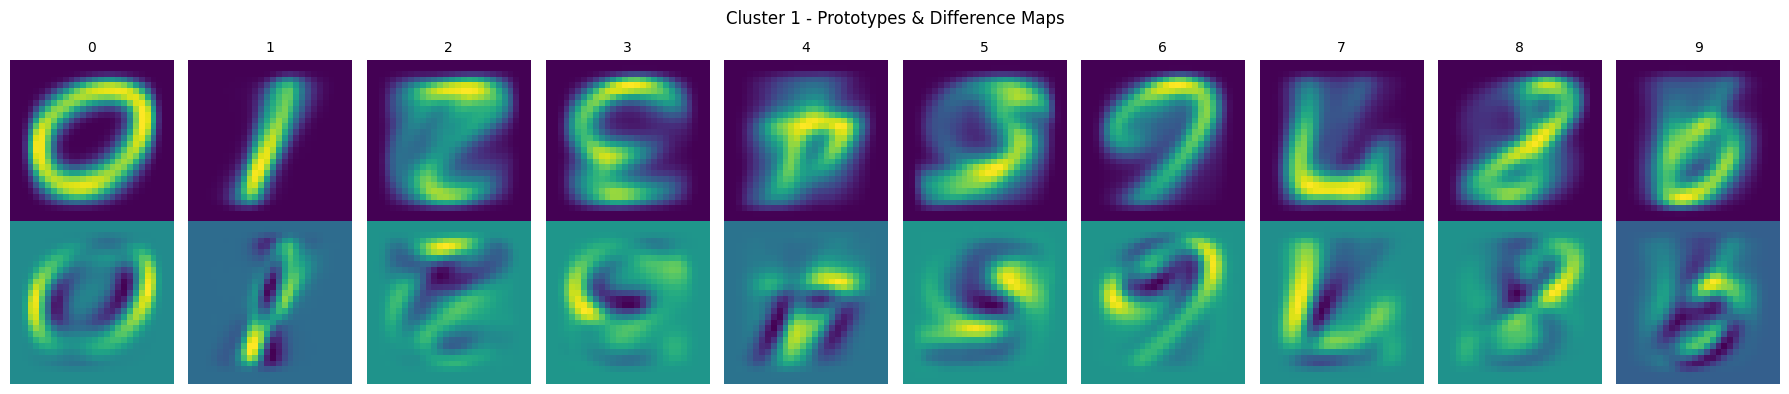

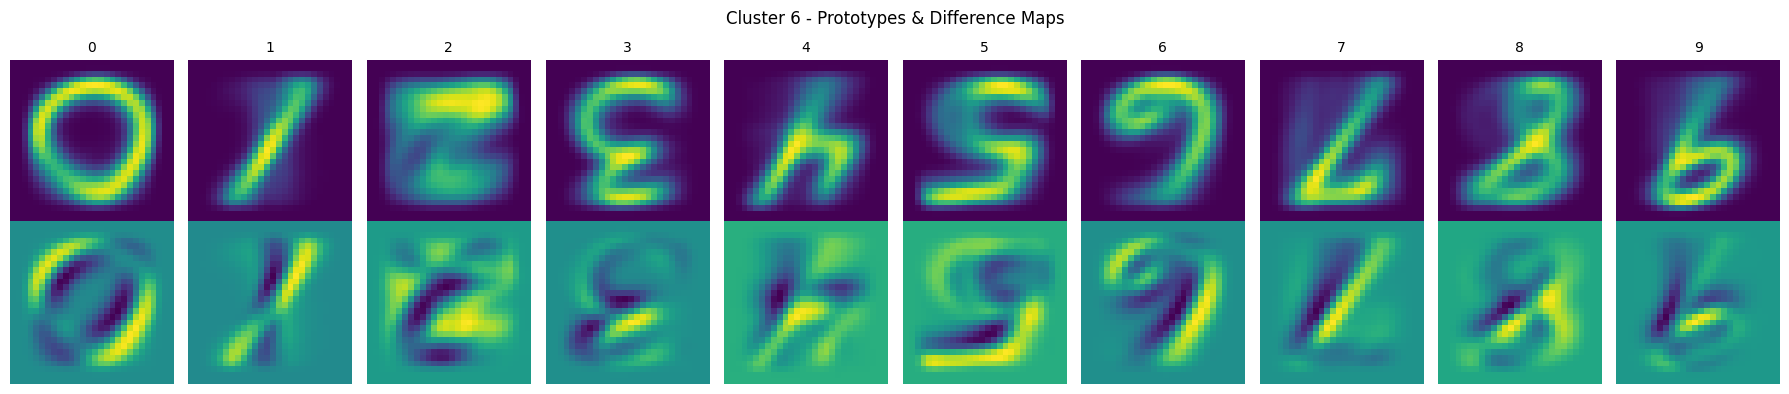

In [ ]:
for cluster_id in cluster_map.keys():
    prototypes_with_diff = funcs.compute_class_conditional_prototypes_with_diff(
        cluster_id, cluster_map, all_neuron_activations, images, labels
    )
    funcs.plot_cluster_prototypes_and_diff(cluster_id, prototypes_with_diff)  # custom plotting function

## cluster extraction